# Training the Segmentation Models

## Loading the database

In [1]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
import numpy as np

IMG_SIZE = 512
BATCH_SIZE = 8
NUM_CLASSES = 1
CROP = "corn"  # "wheat", "sorghum", "corn"

dataset_path = f"../data/{CROP}/"

# --- Custom Dataset for Segmentation ---
class SegmentationDataset(Dataset):
    def __init__(self, root_dir, train=True):
        self.root_dir = root_dir
        self.train = train
        self.img_dir = os.path.join(root_dir, "train/images" if train else "test/images")
        self.mask_dir = os.path.join(root_dir, "train/masks" if train else "test/masks")

        self.image_files = sorted([
            f for f in os.listdir(self.img_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        self.mask_files = sorted([
            f for f in os.listdir(self.mask_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])

        assert len(self.image_files) == len(self.mask_files), \
            f"Image/Mask count mismatch: {len(self.image_files)} vs {len(self.mask_files)}"

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.image_files[idx])
        mask_path = os.path.join(self.mask_dir, self.mask_files[idx])

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")  # grayscale mask

        # --- To Tensor ---
        image = TF.to_tensor(image)
        image = TF.normalize(image, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])

        # Mask → tensor (no normalization)
        mask = torch.from_numpy(np.array(mask)).float().unsqueeze(0)  # [1, H, W]
        mask = (mask > 0).float()

        return image, mask

# --- Datasets & Loaders ---
train_dataset = SegmentationDataset(dataset_path, train=True)
test_dataset = SegmentationDataset(dataset_path, train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

✅ Train size: 16038 | Test size: 5346


In [2]:
for i in range(3):
    img, mask = train_dataset[i]
    print(img.shape, mask.shape)

torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])
torch.Size([3, 512, 512]) torch.Size([1, 512, 512])


## Importing Models

In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


### UNET

In [3]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)
modelName = "U-NET"


c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### DeepLabv3+

In [ ]:
import segmentation_models_pytorch as smp

model = smp.DeepLabV3Plus(
    encoder_name="resnet101",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)
modelName = "DeepLabV3Plus"


### SegFormer

In [ ]:
import torch.nn.functional as F
from transformers import SegformerForSemanticSegmentation

class SegFormerWrapper(torch.nn.Module):
    def __init__(self, num_labels=1):
        super().__init__()
        self.model = SegformerForSemanticSegmentation.from_pretrained(
            "nvidia/mit-b0",
            num_labels=num_labels,
            ignore_mismatched_sizes=True,
        )

    def forward(self, x):
        h, w = x.shape[-2:]
        logits = self.model(pixel_values=x).logits  # [B, num_labels, H/4, W/4]
        return F.interpolate(logits, size=(h, w), mode="bilinear", align_corners=False)

model = SegFormerWrapper(num_labels=1).to(device)
modelName = "SegFormer"


c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\timm\models\layers\__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


### SegNet

In [ ]:
import segmentation_models_pytorch as smp

# SegNet uses a VGG16 encoder with max-pooling indices for unpooling.
# smp provides the closest pre-trained equivalent: VGG16-BN encoder
# with ImageNet weights and a U-Net style decoder.
model = smp.Unet(
    encoder_name="vgg16_bn",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)
modelName = "SegNet"


### MaskFormer

In [ ]:
import torch.nn.functional as F
from transformers import MaskFormerForInstanceSegmentation

class MaskFormerWrapper(torch.nn.Module):
    def __init__(self, num_labels=1):
        super().__init__()
        self.model = MaskFormerForInstanceSegmentation.from_pretrained(
            "facebook/maskformer-swin-small-coco",
            num_labels=num_labels,
            ignore_mismatched_sizes=True,
        )
        self.num_labels = num_labels

    def forward(self, x):
        h, w = x.shape[-2:]
        outputs = self.model(pixel_values=x)
        # class_queries_logits: [B, Q, num_labels+1]  (last dim = "no-object" class)
        # masks_queries_logits: [B, Q, H/4, W/4]
        fg_probs = torch.softmax(outputs.class_queries_logits, dim=-1)[:, :, :self.num_labels]  # [B, Q, num_labels]
        masks = outputs.masks_queries_logits  # [B, Q, H', W']
        combined = torch.einsum("bql,bqhw->blhw", fg_probs, masks)  # [B, num_labels, H', W']
        return F.interpolate(combined, size=(h, w), mode="bilinear", align_corners=False)

model = MaskFormerWrapper(num_labels=1).to(device)
modelName = "MaskFormer"


c:\Users\gnoceras\Documents\SegmentationStudy\.venv\lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


### General Info

In [5]:
print(model)
num_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {num_params:,}")

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

## Training

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import copy
from tqdm import tqdm
import matplotlib.pyplot as plt
import optuna
from torch.utils.data import Subset


In [5]:
# --- Optuna: Bayesian Hyperparameter Optimization ---
# Uses 1/5 of the training data and runs one full epoch per trial.

optuna_size = len(train_dataset) // 5
optuna_indices = list(range(0, len(train_dataset), 5))[:optuna_size]
optuna_subset = Subset(train_dataset, optuna_indices)
optuna_loader = DataLoader(optuna_subset, batch_size=BATCH_SIZE, shuffle=True)

# Snapshot initial weights so every trial starts from the same state
_initial_weights = copy.deepcopy(model.state_dict())

def _optuna_objective(trial):
    model.load_state_dict(copy.deepcopy(_initial_weights))

    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])

    if optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.8, 0.99)
        opt = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=momentum)
    elif optimizer_name == "AdamW":
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:
        opt = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    fn = nn.BCEWithLogitsLoss()
    model.train()
    epoch_loss = 0.0
    for inputs, labels in optuna_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        opt.zero_grad()
        outputs = model(inputs)
        loss = fn(outputs, labels)
        loss.backward()
        opt.step()
        epoch_loss += loss.item()

    return epoch_loss / len(optuna_loader)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler())
study.optimize(_optuna_objective, n_trials=20, show_progress_bar=True)

# Restore model to initial weights before real training
model.load_state_dict(copy.deepcopy(_initial_weights))

best_params = study.best_params
print(f"\nBest hyperparameters: {best_params}")
print(f"Best trial loss:       {study.best_value:.4f}")


Best trial: 10. Best value: 0.127001: 100%|██████████| 20/20 [55:44<00:00, 167.24s/it]


Best hyperparameters: {'lr': 0.0004358450215252325, 'weight_decay': 1.8224406327041852e-06, 'optimizer': 'AdamW'}
Best trial loss:       0.1270


In [6]:
# --- Configuration ---
EPOCHS = 200
early_stopping_patience = 5
best_val_loss = float('inf')
patience_counter = 0
scaler = torch.amp.GradScaler('cuda')

# --- Loss ---
loss_fn = nn.BCEWithLogitsLoss()

# --- Optimizer from Optuna best params ---
_opt_name = best_params.get("optimizer", "Adam")
_lr       = best_params.get("lr", 1e-3)
_wd       = best_params.get("weight_decay", 1e-4)

if _opt_name == "Adam":
    optimizer = optim.Adam(model.parameters(), lr=_lr, weight_decay=_wd)
elif _opt_name == "AdamW":
    optimizer = optim.AdamW(model.parameters(), lr=_lr, weight_decay=_wd)
else:
    _momentum = best_params.get("momentum", 0.9)
    optimizer = optim.SGD(model.parameters(), lr=_lr, weight_decay=_wd, momentum=_momentum)

lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3)

checkpoint_path = os.path.join("../models/", CROP + "_" + modelName + "_seg_rev.pt")
print(f"Model checkpoints will be saved to: {checkpoint_path}")
print(f"Optimizer: {_opt_name} | lr={_lr:.2e} | weight_decay={_wd:.2e}")

# --- Tracking ---
train_losses, val_losses = [], []


Model checkpoints will be saved to: ../models/corn_U-NET_seg_rev.pt
Optimizer: AdamW | lr=4.36e-04 | weight_decay=1.82e-06


In [6]:
if os.path.exists(checkpoint_path):
    print(f"Loading checkpoint from {checkpoint_path}")
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
else:
    print("No checkpoint found, training from scratch.")

No checkpoint found, training from scratch.


In [7]:
# --- Training Loop ---
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    with tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", unit="batch") as tepoch:
        for inputs, labels in tepoch:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                    print("NaN or Inf in model outputs!")
                if torch.isnan(labels).any() or torch.isinf(labels).any():
                    print("NaN or Inf in labels!")
                if labels.sum() == 0:
                    print("Skipping batch with all empty masks")
                    continue
                loss = loss_fn(outputs, labels)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            running_loss += loss.item()
            tepoch.set_postfix(loss=running_loss / (len(tepoch)))
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        with tqdm(test_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - Validation", unit="batch") as vepoch:
            for inputs, labels in vepoch:
                inputs, labels = inputs.to(device), labels.to(device)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    if torch.isnan(outputs).any() or torch.isinf(outputs).any():
                        print("NaN or Inf in model outputs!")
                    if torch.isnan(labels).any() or torch.isinf(labels).any():
                        print("NaN or Inf in labels!")
                    if labels.sum() == 0:
                        print("Skipping batch with all empty masks")
                        continue
                    loss = loss_fn(outputs, labels)
                    preds = (torch.sigmoid(outputs) > 0.5).float()
                val_correct += (preds == labels).sum().item()
                val_total += labels.numel()
                val_acc = val_correct / val_total if val_total > 0 else 0
                val_loss += loss.item()
                vepoch.set_postfix(loss=val_loss / (len(vepoch)))

    avg_val_loss = val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} - Val Loss: {avg_val_loss:.4f} - Val Acc: {val_acc:.4f}%")

    # --- Scheduler step (use validation loss) ---
    lr_scheduler.step(avg_val_loss)

    # --- Checkpointing ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"✅ Model improved (Val Loss={avg_val_loss:.3f}), saved to {checkpoint_path}")
    else:
        patience_counter += 1
        print(f"🔴 No improvement, patience counter: {patience_counter}")

    if patience_counter >= early_stopping_patience:
        print("🛑 Early stopping triggered!")
        break

Epoch 1/200 - Validation:  55%|█████▍    | 366/669 [00:52<00:39,  7.60batch/s, loss=0.0432] 

Skipping batch with all empty masks


Epoch 1/200 - Validation: 100%|██████████| 669/669 [01:33<00:00,  7.15batch/s, loss=0.0636]


Epoch 1 - Val Loss: 0.0636 - Val Acc: 0.9748%
✅ Model improved (Val Loss=0.064), saved to ../models/corn_U-NET_seg_rev.pt


Epoch 2/200 - Validation:  55%|█████▍    | 366/669 [00:53<00:39,  7.58batch/s, loss=0.0403] 

...

Epoch 6 - Val Loss: 0.0798 - Val Acc: 0.9801%
🔴 No improvement, patience counter: 4


Epoch 7/200 - Validation:  55%|█████▍    | 366/669 [00:41<00:33,  9.08batch/s, loss=0.0645] 

Skipping batch with all empty masks


Epoch 7/200 - Validation: 100%|██████████| 669/669 [01:16<00:00,  8.75batch/s, loss=0.0845]

Epoch 7 - Val Loss: 0.0845 - Val Acc: 0.9802%
🔴 No improvement, patience counter: 5
🛑 Early stopping triggered!


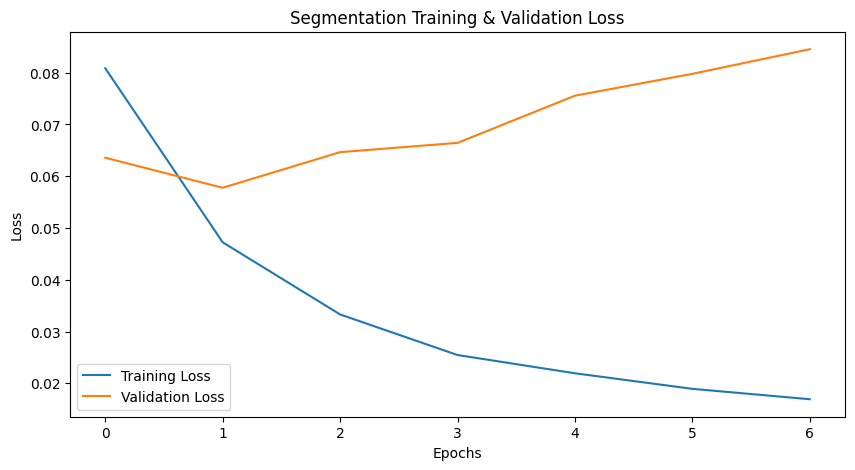

In [8]:
# --- Plot losses ---
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Segmentation Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inference on Test Image

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_25620\2977633742.py:12: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


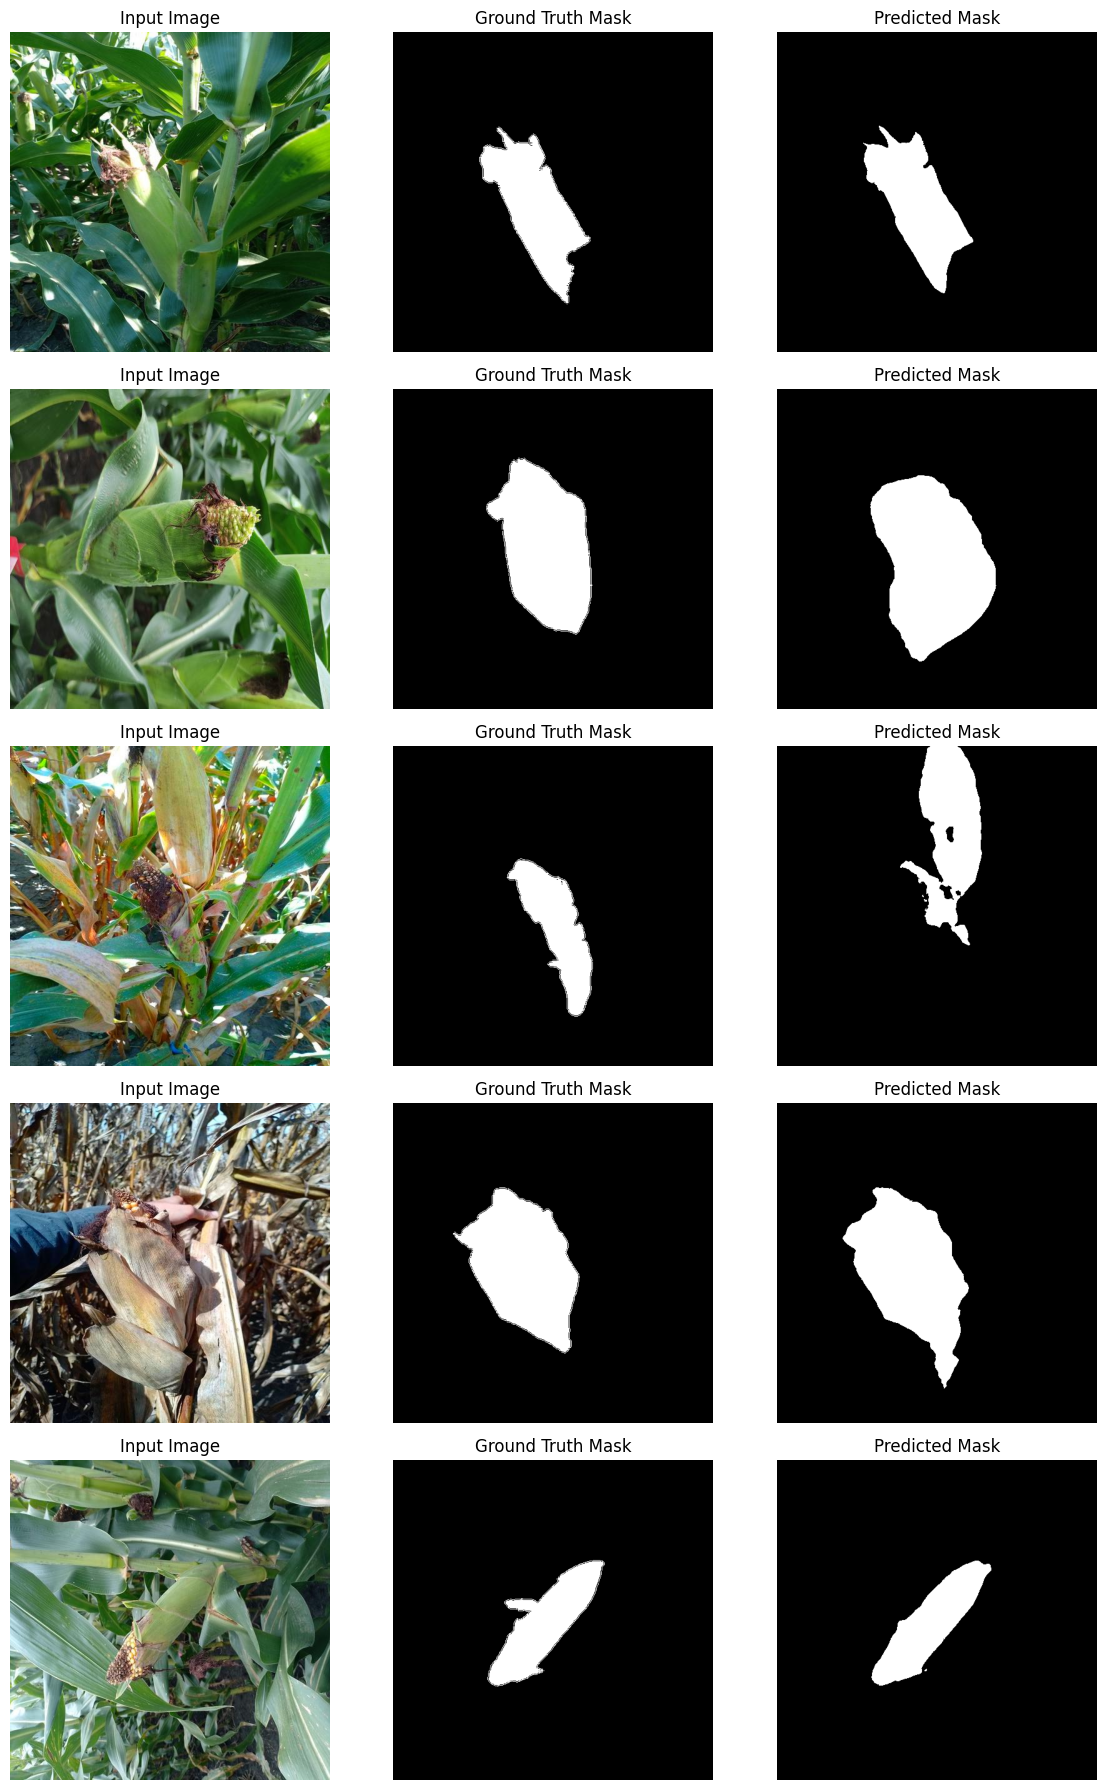

In [9]:
import random

# Pick 5 random indices from the test dataset
indices = random.sample(range(len(test_dataset)), 5)

fig, axs = plt.subplots(5, 3, figsize=(12, 18))
for i, idx in enumerate(indices):
    img, mask = test_dataset[idx]
    img_input = img.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            pred_logits = model(img_input)
            pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()
    axs[i, 0].imshow(img.permute(1, 2, 0).cpu() * 0.5 + 0.5)
    axs[i, 0].set_title("Input Image")
    axs[i, 1].imshow(mask.squeeze().cpu(), cmap='gray')
    axs[i, 1].set_title("Ground Truth Mask")
    axs[i, 2].imshow(pred_mask, cmap='gray')
    axs[i, 2].set_title("Predicted Mask")
    for j in range(3):
        axs[i, j].axis('off')
plt.tight_layout()
plt.show()


In [10]:
import time
from PIL import Image
import torchvision.transforms.functional as TF

# --- Config ---
IMG_PATH = "../data/{}/test/images/1_1_4.jpg".format(CROP)  # <-- set your image path

model.eval()

# --- Preprocess image ---
img = Image.open(IMG_PATH).convert("RGB")
img = img.resize((512, 512))  # resize if needed
img_tensor = TF.to_tensor(img)
img_tensor = TF.normalize(img_tensor, mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
img_tensor = img_tensor.unsqueeze(0).to(device)

# --- Inference with timing ---
with torch.no_grad():
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    start = time.time()
    with torch.cuda.amp.autocast():
        pred_logits = model(img_tensor)
    torch.cuda.synchronize() if torch.cuda.is_available() else None
    end = time.time()
    pred_mask = (torch.sigmoid(pred_logits) > 0.5).float().cpu().squeeze().numpy()

print(f"Inference time: {end - start:.4f} seconds")

C:\Users\gnoceras\AppData\Local\Temp\ipykernel_25620\961485312.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Inference time: 0.2351 seconds
